# Advanced Certification Program in Computational Data Science
## A program by IISc and TalentSprint
### Mini-Project: Exploratory Data Analysis - Timeseries

## Problem Statement

Perform Exploratory Data Analysis (EDA) of Retail Sales time series data using visualizations and statistical methods.

## Learning Objectives

At the end of the mini-project, you will be able to :

* perform Exploratory data analysis (EDA) of the time series
* perform Time series behaviour analysis in qualitative and quantitative terms
* summarize the findings based on the EDA

## Dataset

The dataset is a French retail company quarterly sales data that has been made available from  Prof. Rob Hyndman's ["Forecasting Methods & Applications"](https://robjhyndman.com/forecasting/) book. There are 24 entries, from 2012-03-31 to 2017-12-31 (Quarterly sales values).

## Introduction

Exploratory data analysis of time series data starts with data visualization. 

- Are there consistent patterns? 
- Is there a significant trend? 
- Is seasonality important? 
- Is there evidence of the presence of business cycles? 
- Are there any outliers in the data that need to be explained by those with expert knowledge? 
- How strong are the relationships among the variables available for analysis?

Various tools have been developed to help with these analyses. 

## Grading = 10 Points

In [2]:
#@title Download Dataset
!wget -qq https://cdn.iisc.talentsprint.com/CDS/Datasets/ts_frenchretail.csv

### Importing libraries


In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-white')
%matplotlib inline
import scipy
from pandas.plotting import lag_plot
from statsmodels.graphics.tsaplots import month_plot, seasonal_plot, quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import signal
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

from dateutil.parser import parse
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.tsa.stattools import grangercausalitytests

### Import the Data

In [76]:
# Read dataset with 'Date' as index
retaildata = pd.read_csv("/content/ts_frenchretail.csv", index_col = 'Date')

In [ ]:
retaildata.tail()

,Sales
Date,
12/31/2016,592000
3/31/2017,627000
6/30/2017,725000
9/30/2017,854000
12/31/2017,661000


## Exploratory Data Analysis

### **Preprocessing** (1 point)

#### Divide the sales by 1000

Sales numbers are in thousands, so divide by 1000 to make it easier to work with numbers

In [77]:
retaildata['Sales'] = retaildata['Sales'].div(1000).round(2)

In [ ]:
retaildata.tail()


,Sales
Date,
12/31/2016,592.0
3/31/2017,627.0
6/30/2017,725.0
9/30/2017,854.0
12/31/2017,661.0


#### Check for missing values     

In [ ]:
retaildata.isna().sum().sum()
retaildata.isnull().sum().sum()

0

### **Visualization**

#### Visualize the time series (2012 to 2017) (1 point)

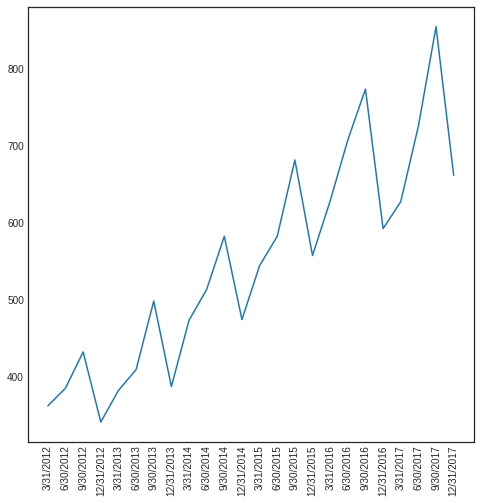

In [147]:
plt.figure(figsize=(8,8)) 
plt.xticks(rotation = 90)
plt.plot(retaildata.index,retaildata.Sales)

#### Visualize the data year-wise and quarter-wise (2 points)

- Box plot to see distribution of sales in each year
- Create year-wise subplots to visualize the quarterly Sales per year
- Compute Percentage growth each year

Make a report of your observations.

In [78]:
retaildata['Year'] = pd.DatetimeIndex(retaildata.index).year
retaildata['Month'] = pd.DatetimeIndex(retaildata.index).month

In [ ]:
retaildata.head()

,Sales,Year,Month
Date,,,
3/31/2012,362.0,2012,3
6/30/2012,385.0,2012,6
9/30/2012,432.0,2012,9
12/31/2012,341.0,2012,12
3/31/2013,382.0,2013,3


<Figure size 720x720 with 0 Axes>

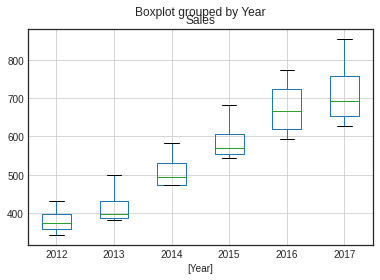

In [ ]:
# Box plot to see distribution of sales in each year
plt.figure(figsize=(10,10))
retaildata.boxplot(column=['Sales'], by=['Year'])

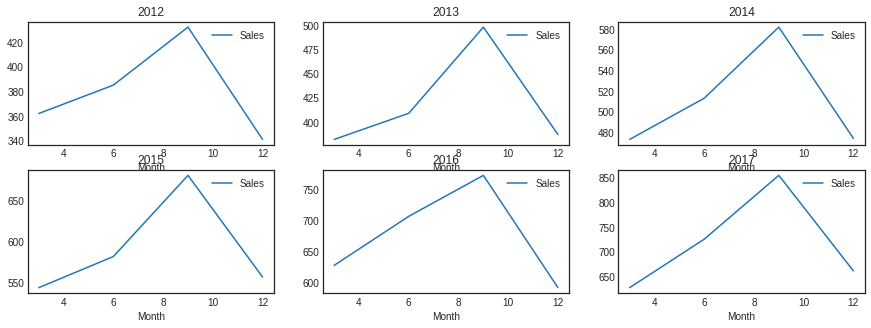

In [ ]:
# Create year-wise subplots to visualize the quarterly Sales per year
#plot data
fig, axes = plt.subplots(2,3, figsize=(15,5))
for (year, group), ax in zip(retaildata.groupby('Year'), axes.flatten()):
    group.plot(x='Month', y='Sales', kind='line', ax=ax, title=year)

In [79]:
# Percentage growth each year
# Calculating a simple moving average
retaildata['SMA'] = retaildata['Sales'].rolling(4).mean()
retaildata

,Sales,Year,Month,SMA
Date,,,,
3/31/2012,362.0,2012,3,NaN
6/30/2012,385.0,2012,6,NaN
9/30/2012,432.0,2012,9,NaN
12/31/2012,341.0,2012,12,380.00
3/31/2013,382.0,2013,3,385.00
6/30/2013,409.0,2013,6,391.00
9/30/2013,498.0,2013,9,407.50
12/31/2013,387.0,2013,12,419.00
3/31/2014,473.0,2014,3,441.75


In [80]:
retaildata['percentGrowthInSMA'] = retaildata['SMA'].pct_change().mul(100)

In [ ]:
retaildata

,Sales,Year,Month,SMA,percentGrowthInSMA
Date,,,,,
3/31/2012,362.0,2012,3,NaN,NaN
6/30/2012,385.0,2012,6,NaN,NaN
9/30/2012,432.0,2012,9,NaN,NaN
12/31/2012,341.0,2012,12,380.00,NaN
3/31/2013,382.0,2013,3,385.00,1.315789
6/30/2013,409.0,2013,6,391.00,1.558442
9/30/2013,498.0,2013,9,407.50,4.219949
12/31/2013,387.0,2013,12,419.00,2.822086
3/31/2014,473.0,2014,3,441.75,5.429594


#### Visualize the distribution of the Sales (0.5 point)

While normally distributed data is not a requirement for forecasting and doesn't necessarily improve point forecast accuracy, it can help stablize the variance and narrow the prediction interval.

Report your observations.

Hint: `sns.distplot()`

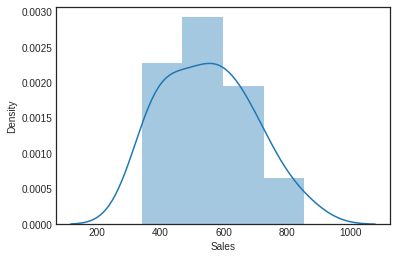

In [ ]:
sns.distplot(retaildata.Sales)

#### Visualize Quarterly trends (1 point)

Create quarterly subplots to visualize the data in each quarter across all years

Hint: statsmodels' `quarter_plot()` method

In [109]:
dt_retaildata = pd.read_csv("/content/ts_frenchretail.csv")
dt_retaildata['Sales'] = dt_retaildata['Sales'].div(1000).round(2)
dt_retaildata1 = dt_retaildata.iloc[0:1]
dt_retaildata1
dt_retaildata2 = dt_retaildata.iloc[4:5]
dt_retaildata2
dt_retaildata3 = dt_retaildata.iloc[8:9]
dt_retaildata3
dt_retaildata4 = dt_retaildata.iloc[12:13]
dt_retaildata4
dt_retaildata5 = dt_retaildata.iloc[16:17]
dt_retaildata5
dt_retaildata6 = dt_retaildata.iloc[20:21]
dt_retaildata6
dt_retaildata_q1 = pd.concat([dt_retaildata1,dt_retaildata2,dt_retaildata3,dt_retaildata4,dt_retaildata5,dt_retaildata6])
dt_retaildata_q1

,Date,Sales
0,3/31/2012,362.0
4,3/31/2013,382.0
8,3/31/2014,473.0
12,3/31/2015,544.0
16,3/31/2016,628.0
20,3/31/2017,627.0


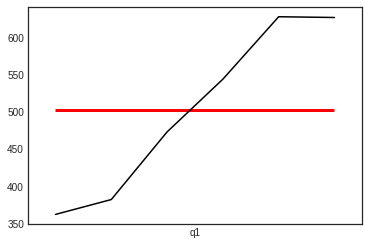

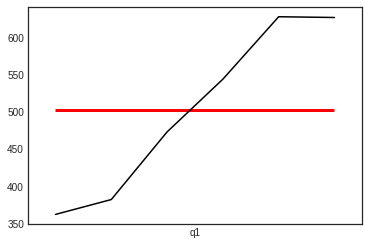

In [66]:
# Graph for Q1 across 6 years (Same graph gets repeated 2 times)
dt_retaildata_q1.index = pd.PeriodIndex(pd.to_datetime(dt_retaildata_q1.Date),freq='Q')
quarter_plot(dt_retaildata_q1['Sales'])

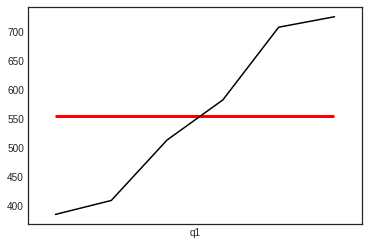

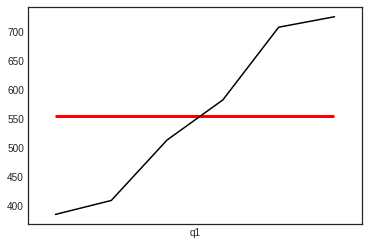

In [68]:
# Graph for Q2 across 6 years (Same graph gets repeated 2 times)
dt_retaildata1 = dt_retaildata.iloc[1:2]
dt_retaildata1
dt_retaildata2 = dt_retaildata.iloc[5:6]
dt_retaildata2
dt_retaildata3 = dt_retaildata.iloc[9:10]
dt_retaildata3
dt_retaildata4 = dt_retaildata.iloc[13:14]
dt_retaildata4
dt_retaildata5 = dt_retaildata.iloc[17:18]
dt_retaildata5
dt_retaildata6 = dt_retaildata.iloc[21:22]
dt_retaildata6
dt_retaildata_q2 = pd.concat([dt_retaildata1,dt_retaildata2,dt_retaildata3,dt_retaildata4,dt_retaildata5,dt_retaildata6])
dt_retaildata_q2
dt_retaildata_q2.index = pd.PeriodIndex(pd.to_datetime(dt_retaildata_q2.Date),freq='Q')
quarter_plot(dt_retaildata_q2['Sales'])

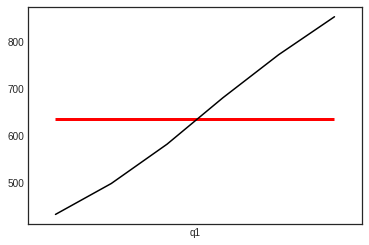

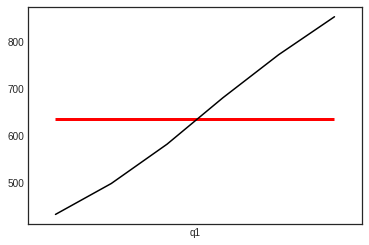

In [69]:
# Graph for Q3 across 6 years (Same graph gets repeated 2 times)
dt_retaildata1 = dt_retaildata.iloc[2:3]
dt_retaildata1
dt_retaildata2 = dt_retaildata.iloc[6:7]
dt_retaildata2
dt_retaildata3 = dt_retaildata.iloc[10:11]
dt_retaildata3
dt_retaildata4 = dt_retaildata.iloc[14:15]
dt_retaildata4
dt_retaildata5 = dt_retaildata.iloc[18:19]
dt_retaildata5
dt_retaildata6 = dt_retaildata.iloc[22:23]
dt_retaildata6
dt_retaildata_q3 = pd.concat([dt_retaildata1,dt_retaildata2,dt_retaildata3,dt_retaildata4,dt_retaildata5,dt_retaildata6])
dt_retaildata_q3
dt_retaildata_q3.index = pd.PeriodIndex(pd.to_datetime(dt_retaildata_q3.Date),freq='Q')
quarter_plot(dt_retaildata_q3['Sales'])

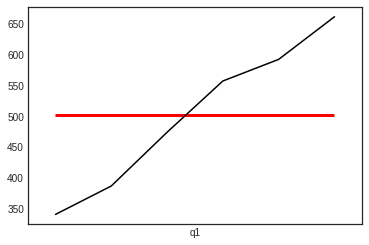

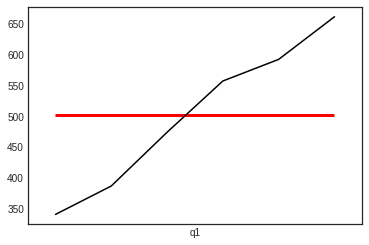

In [72]:
# Graph for Q4 across 6 years (Same graph gets repeated 2 times)
dt_retaildata1 = dt_retaildata.iloc[3:4]
dt_retaildata1
dt_retaildata2 = dt_retaildata.iloc[7:8]
dt_retaildata2
dt_retaildata3 = dt_retaildata.iloc[11:12]
dt_retaildata3
dt_retaildata4 = dt_retaildata.iloc[15:16]
dt_retaildata4
dt_retaildata5 = dt_retaildata.iloc[19:20]
dt_retaildata5
dt_retaildata6 = dt_retaildata.iloc[23:24]
dt_retaildata6
dt_retaildata_q4 = pd.concat([dt_retaildata1,dt_retaildata2,dt_retaildata3,dt_retaildata4,dt_retaildata5,dt_retaildata6])
dt_retaildata_q4
dt_retaildata_q4.index = pd.PeriodIndex(pd.to_datetime(dt_retaildata_q4.Date),freq='Q')
quarter_plot(dt_retaildata_q4['Sales'])

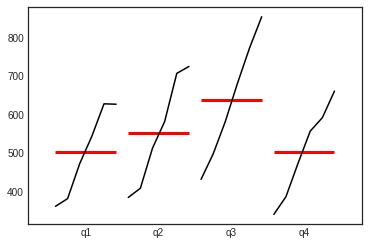

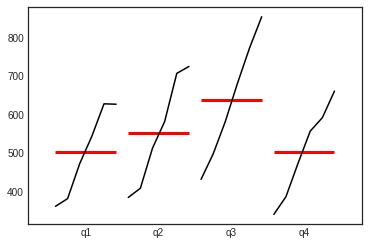

In [74]:
# Combining Q1, Q2, Q3, Q4 across 2012-2017 (6 years) (Same graph gets repeated 2 times)
dt_retaildata_q1_q2_q3_q4 = pd.concat([dt_retaildata_q1,dt_retaildata_q2,dt_retaildata_q3,dt_retaildata_q4])
dt_retaildata_q1_q2_q3_q4.index = pd.PeriodIndex(pd.to_datetime(dt_retaildata_q1_q2_q3_q4.Date),freq='Q')
quarter_plot(dt_retaildata_q1_q2_q3_q4['Sales'])

#### Visualize the distribution of Sales in each year within a single plot (1 point)

- Do the distribution peaks shift to the right from 2012 to 2017? What does this indicate?
- Is there a change in the width of the distributions from 2012 to 2017? What does it signify?

Hint: `sns.distplot(hist=False)`

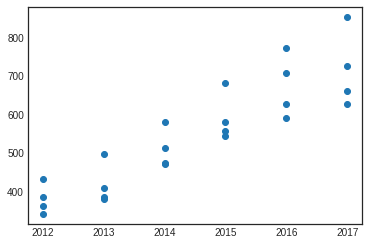

In [94]:
# Distribution plot of each year
plt.scatter(retaildata.Year,retaildata.Sales)

#Do the distribution peaks shift to the right from 2012 to 2017? What does this indicate?
# Yes, increase in overall sales

#Is there a change in the width of the distributions from 2012 to 2017? What does it signify?
# Yes, the factor which is causing the seasonality/cyclic behavior has also increased over the years.
# Some Quarters have much higher sales each year and this skew has increased over the years.

#### Visualize the quarterly sales for each year using a stacked bar plot (1 point)

In [110]:
dt_retaildata['Quarter'] = pd.PeriodIndex(pd.to_datetime(dt_retaildata.Date),freq='Q')
dt_retaildata
dt_retaildata['Year'] = pd.DatetimeIndex(dt_retaildata.Date).year
dt_retaildata = dt_retaildata.drop(['Date'],axis=1)
dt_retaildata

,Sales,Quarter,Year
0,362.0,2012Q1,2012
1,385.0,2012Q2,2012
2,432.0,2012Q3,2012
3,341.0,2012Q4,2012
4,382.0,2013Q1,2013
5,409.0,2013Q2,2013
6,498.0,2013Q3,2013
7,387.0,2013Q4,2013
8,473.0,2014Q1,2014
9,513.0,2014Q2,2014


In [122]:
dt_retaildata['Q'] = dt_retaildata['Quarter'].astype(str).str[-2:]
dt_retaildata

,Sales,Quarter,Year,Q
0,362.0,2012Q1,2012,Q1
1,385.0,2012Q2,2012,Q2
2,432.0,2012Q3,2012,Q3
3,341.0,2012Q4,2012,Q4
4,382.0,2013Q1,2013,Q1
5,409.0,2013Q2,2013,Q2
6,498.0,2013Q3,2013,Q3
7,387.0,2013Q4,2013,Q4
8,473.0,2014Q1,2014,Q1
9,513.0,2014Q2,2014,Q2


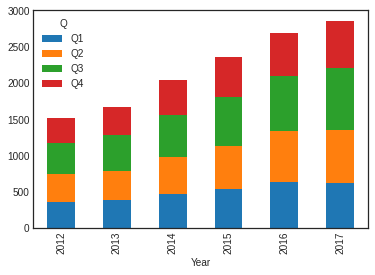

In [124]:
dt_retaildata.pivot_table(index = 'Year', columns = 'Q' , values = 'Sales').plot(kind = 'bar', stacked = True)

#### Check if the time series data is stationary (1 point)

Hint:

For the series to be stationary, it must have:
 - constant mean
 - constant variance
 - constant covariance (uncorrelated)

Visualize if the mean is constant

Hint: [Rolling mean](https://pandas.pydata.org/docs/reference/api/pandas.core.window.rolling.Rolling.mean.html)

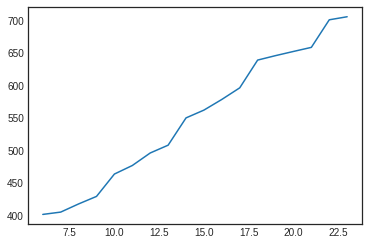

In [142]:
# Visualize Rolling mean - its not constant
dt_retaildata['RollingMean'] = dt_retaildata['Sales'].rolling(7).mean()
dt_retaildata.RollingMean.plot()

Visualize if the variance is constant

Hint: [Rolling standard deviation](https://pandas.pydata.org/docs/reference/api/pandas.core.window.rolling.Rolling.std.html)

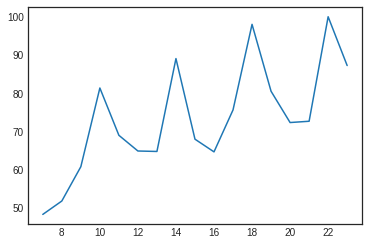

In [144]:
# Rolling standard deviation - Its not constant
dt_retaildata['RollingSTD'] = dt_retaildata['Sales'].rolling(8).std()
dt_retaildata.RollingSTD.plot()

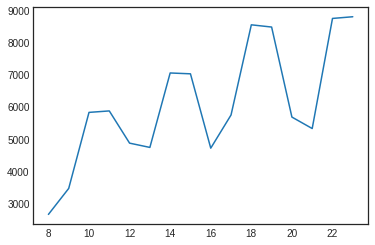

In [146]:
# Visualize Rolling Covariance - Its not constant
dt_retaildata['RollingCov'] = dt_retaildata['Sales'].rolling(9).cov()
dt_retaildata.RollingCov.plot()

Based on the observations report whether the series is stationary or not.

In [ ]:
# Series is not stationary

#### Visualize the patterns in time series - trend, seasonality, residuals (1 point)

Hint: See Module 6 - AST3 EDA > Patterns in a time series

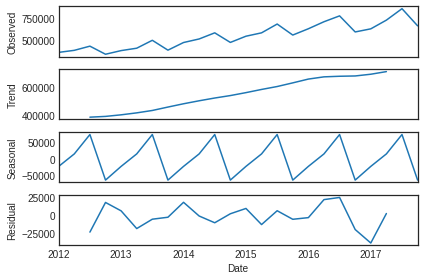

In [137]:
# Applying seasonal decompose
# Setting index back to date
df = pd.read_csv("/content/ts_frenchretail.csv", parse_dates=['Date'], index_col='Date')

# Applying seasonal decompose
result = seasonal_decompose(df, model='additive')

# Plotting trend, seasonality, Residuals in sales data
result.plot()
plt.show()

Report if there are any observable patterns in terms of trend, seasonality , or cyclic behavior.

In [ ]:
# Yes, there is an observable upwards trend as well as quarterwise spikes in sales

# Since in this case we are evaluating against a calendar, the timeseries seems to be seasonal rather than cyclic.
# Cyclic behavior is due to business or other reasons rather than time of the year. If we have more information 
# regarding the business, we can better evaluate if its seasonal or cyclic since in each year, there seems to be a
# cyclic behavior towards the 4th Quarter.
# 4th Quarter is also during December, Christmas and holiday season. So depending on the business it could be
# seasonal/cyclic.
 

### **Detrending**

####  Detrend the time series (0.5 point)

Detrending a time series is to remove the trend component from a time series.

Hint: 
- Subtract the line of best fit `scipy.signal.detrend()`

Text(0.5, 1.0, 'Sales detrended by subtracting the least squares fit')

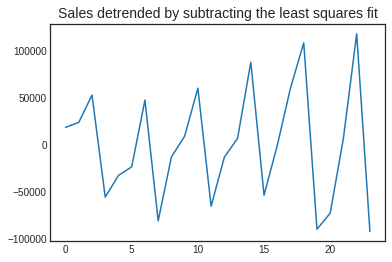

In [138]:
# Using scipy: Subtract the line of best fit
detrended = signal.detrend(df.Sales.values)
plt.plot(detrended)
plt.title('Sales detrended by subtracting the least squares fit', fontsize=14)

Text(0.5, 1.0, 'Sales detrended by subtracting the trend component')

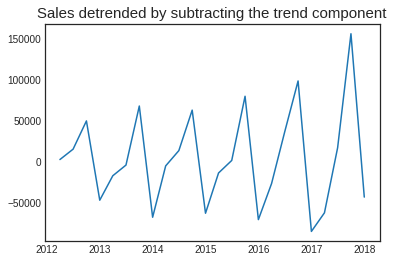

In [139]:
# Decomposing time-series first
result_mul = seasonal_decompose(df['Sales'], model='multiplicative', extrapolate_trend='freq')
# Detrending the time-series by trend component
detrended = df.Sales.values - result_mul.trend

# Plotting the detrended time series
plt.plot(detrended)
plt.title('Sales detrended by subtracting the trend component', fontsize=15)

### **Lag Plots** (Optional)

#### Visualize the Lag plots

A Lag plot is a scatter plot of a time series against a lag of itself. It is normally used to check for autocorrelation. If there is any pattern existing in the series, the series is autocorrelated. If there is no such pattern, the series is likely to be random white noise.

For reference, see Module 6 - AST3 > Lag Plots 

Hint: `pandas.plotting.lag_plot()`

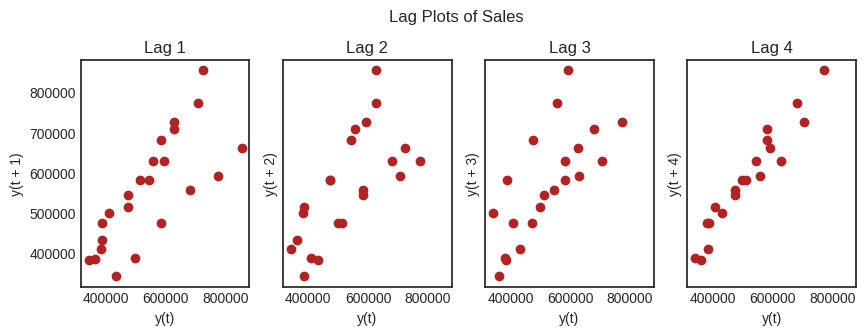

In [141]:
# Visualize lag plots
fig, axes = plt.subplots(1, 4, figsize=(10,3), sharex=True, sharey=True, dpi=100)
for i, ax in enumerate(axes.flatten()[:4]):
    lag_plot(df.Sales, lag=i+1, ax=ax, c='firebrick')
    ax.set_title('Lag ' + str(i+1))

fig.suptitle('Lag Plots of Sales', y=1.05)    
plt.show()

### Report Analysis

- Give the summary about this time series